In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('Mall_Customers.csv')

In [4]:
data


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


# Basic checks

In [5]:
data.shape

(200, 5)

In [6]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
data.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [8]:
data.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [10]:
data.dtypes


,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [11]:
num_cols = data.select_dtypes(include=['int64','float64'])
num_cols

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40
...,...,...,...,...
195,196,35,120,79
196,197,45,126,28
197,198,32,126,74
198,199,32,137,18


In [12]:
cat_cols = data.select_dtypes(include='object')
cat_cols

,Gender
0,Male
1,Male
2,Female
3,Female
4,Female
...,...
195,Female
196,Female
197,Male
198,Male


In [13]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [14]:
data.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [15]:
data.duplicated().sum()

np.int64(0)

# EDA

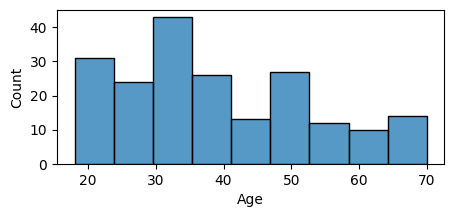

In [16]:
# check distribution of Age,Annual Income (k$)	Spending Score (1-100)
plt.figure(figsize=(5,2))
sns.histplot(data,x='Age')
plt.show()

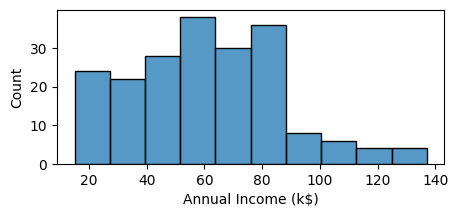

In [17]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='Annual Income (k$)')
plt.show()

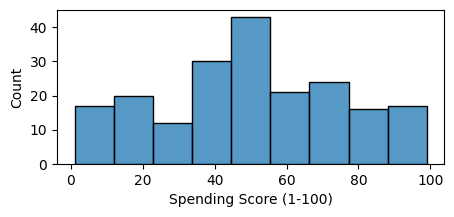

In [18]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='Spending Score (1-100)')
plt.show()

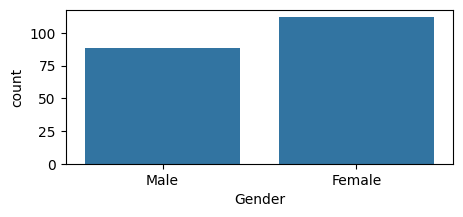

In [19]:
# visualise the count of male and female
plt.figure(figsize=(5,2))
sns.countplot(data,x='Gender')
plt.show()

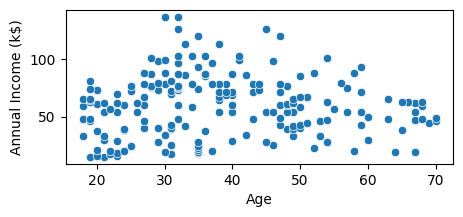

In [20]:
# relationship between Age and Income
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='Age',y='Annual Income (k$)')
plt.show()

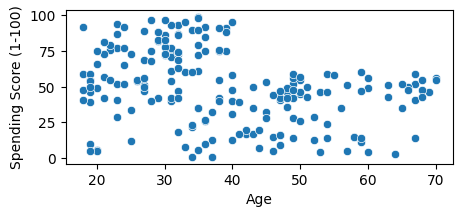

In [21]:
# relationship between Age and Spending Score (1-100)
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='Age',y='Spending Score (1-100)')
plt.show()

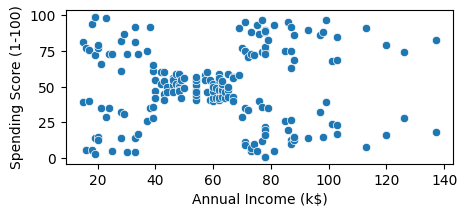

In [22]:
# relationship between Annual Income (k$)	Spending Score (1-100)
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='Annual Income (k$)',y='Spending Score (1-100)')
plt.show()

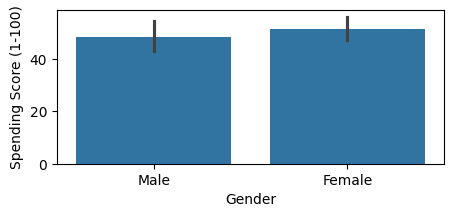

In [23]:
# average  Spending Score with Gender
plt.figure(figsize=(5,2))
sns.barplot(data,x='Gender',y='Spending Score (1-100)')
plt.show()

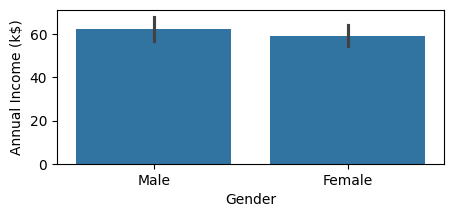

In [24]:
# average  Annual Income with Gender
plt.figure(figsize=(5,2))
sns.barplot(data,x='Gender',y='Annual Income (k$)')
plt.show()

# Encoding

In [26]:
# gender --> one hot encoding
data = pd.get_dummies(data,columns=['Gender'],dtype='int')
data

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male
0,1,19,15,39,0,1
1,2,21,15,81,0,1
2,3,20,16,6,1,0
3,4,23,16,77,1,0
4,5,31,17,40,1,0
...,...,...,...,...,...,...
195,196,35,120,79,1,0
196,197,45,126,28,1,0
197,198,32,126,74,0,1
198,199,32,137,18,0,1


In [27]:
# Scaling

In [28]:
from sklearn.preprocessing import StandardScaler
model =  StandardScaler()
data[['Age']]= model.fit_transform(data[['Age']])
data[['Annual Income (k$)']]= model.fit_transform(data[['Annual Income (k$)']])
data[['Spending Score (1-100)']]= model.fit_transform(data[['Spending Score (1-100)']])



In [29]:
# drop the customerid column
data.drop(columns='CustomerID',inplace=True)

# KMean Implementation

In [30]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3)
model.fit(data)

KMeans(n_clusters=3)

In [31]:
df = data.copy()

In [32]:
df['cluster']= model.predict(data)

In [33]:
df['cluster'].unique()

array([0, 2, 1], dtype=int32)

In [34]:
labels = model.predict(data)

In [35]:
from sklearn.metrics import silhouette_score
silhouette_score(data,labels)

np.float64(0.2879173501021572)

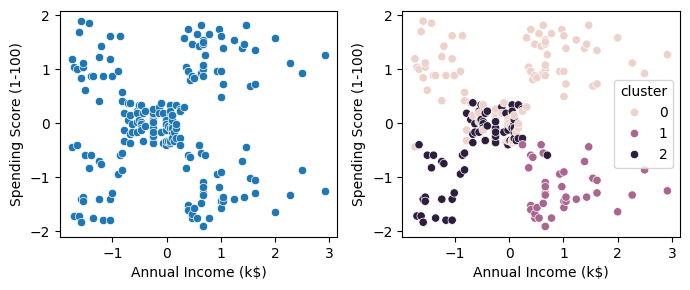

In [36]:
fig,ax = plt.subplots(1,2,figsize=(7,3))
sns.scatterplot(df,x='Annual Income (k$)',y='Spending Score (1-100)',ax=ax[0])
sns.scatterplot(df,x='Annual Income (k$)',y='Spending Score (1-100)',
                hue='cluster',ax=ax[1])
plt.tight_layout()


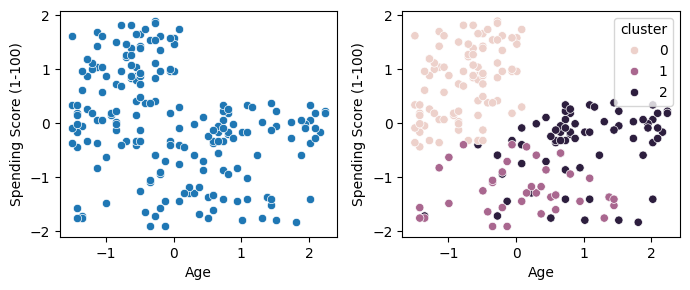

In [37]:
fig,ax = plt.subplots(1,2,figsize=(7,3))
sns.scatterplot(df,x='Age',y='Spending Score (1-100)',ax=ax[0])
sns.scatterplot(df,x='Age',y='Spending Score (1-100)',
                hue='cluster',ax=ax[1])
plt.tight_layout()

# Elbow Method

In [38]:
wcss = []
for k in range(2,11):
  model = KMeans(n_clusters=k)
  model.fit(data)
  wcss.append(model.inertia_)

In [39]:
wcss

[487.65863415711783,
 393.68908873387954,
 303.34066704491033,
 266.250206178307,
 240.5381636969314,
 205.76748357470763,
 206.60504010218912,
 178.10063975697406,
 158.65549818411958]

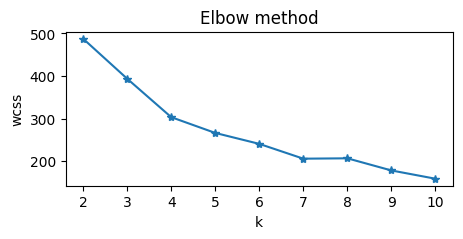

In [40]:
plt.figure(figsize=(5,2))
plt.plot(range(2,11),wcss,marker='*')
plt.xlabel('k')
plt.ylabel('wcss')
plt.title('Elbow method')
plt.show()

In [41]:
model = KMeans(n_clusters=4)
model.fit(data)

KMeans(n_clusters=4)

In [42]:
df1 = data.copy()

In [43]:
df1['cluster'] = model.predict(data)

In [44]:
labels =model.predict(data)

In [45]:
silhouette_score(data,labels)

np.float64(0.23358020702052515)

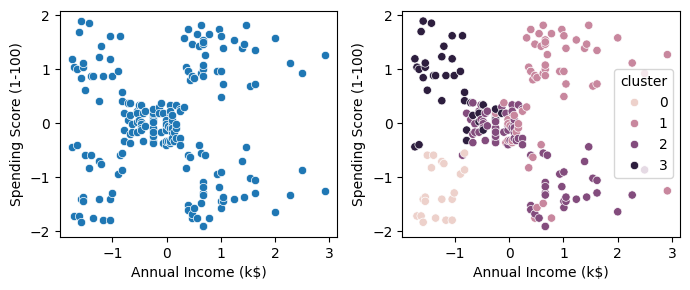

In [46]:
fig,ax = plt.subplots(1,2,figsize=(7,3))
sns.scatterplot(df1,x='Annual Income (k$)',y='Spending Score (1-100)',ax=ax[0])
sns.scatterplot(df1,x='Annual Income (k$)',y='Spending Score (1-100)',
                hue='cluster',ax=ax[1])
plt.tight_layout()